In [ ]:
EXPERIMENT 5

In [ ]:
Scenario 1: K-Nearest Neighbors (KNN) - Breast Cancer Classification

Predict whether a tumor is Benign or Malignant based on medical measurements using K-Nearest Neighbors.

Dataset: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

In [ ]:
Objective:

To implement a KNN classifier to predict tumor diagnosis and analyze model performance with different values of K.

In [ ]:
Target Variable: Diagnosis (Benign / Malignant)

Input Features: Radius, Texture, Perimeter, Area, Smoothness


K.Nivedha(24BAD082)

EXPERIMENT 5

SCENARIO 1: KNN Classification

Best K: 9

Accuracy: 0.9298245614035088

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



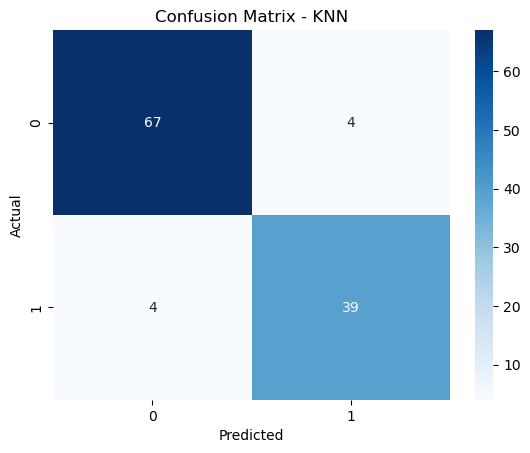

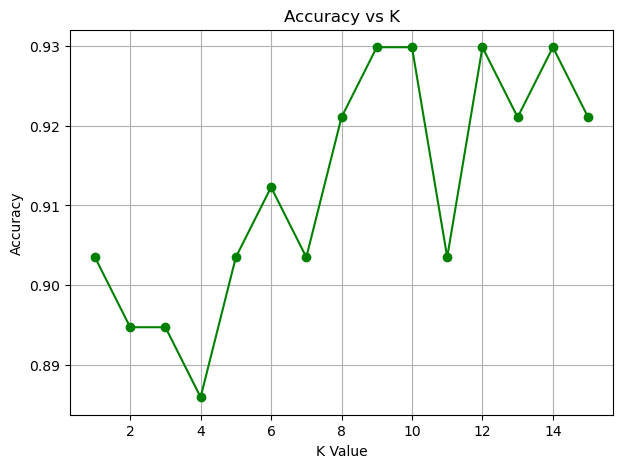

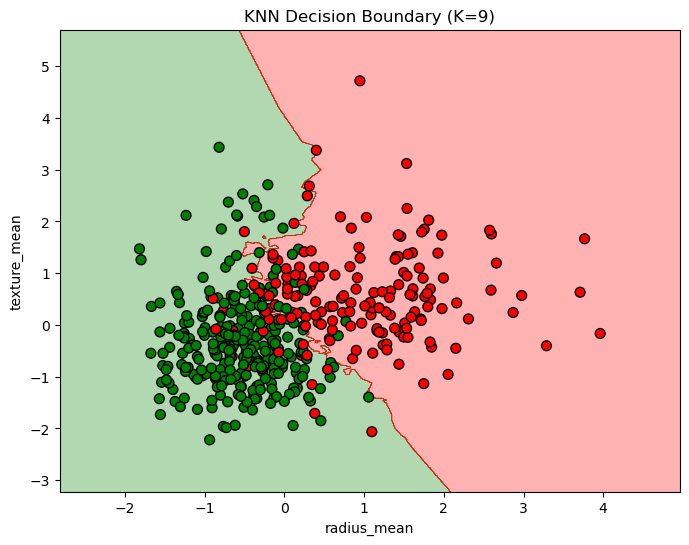

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 5")
print("\nSCENARIO 1: KNN Classification\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

#Load Dataset 
df = pd.read_csv(r"C:\Users\nived\Downloads\breast-cancer.csv")  

#Check columns
#print(df.columns)  

#Encode target variable
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # Benign=0, Malignant=1

#Select two features for visualization (Decision Boundary)
features = ['radius_mean', 'texture_mean']  # make sure these exist in CSV
X = df[features]
y = df['diagnosis']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Experiment with different K
accuracy_list = []
k_range = range(1, 16)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy_list.append(accuracy_score(y_test, y_pred))

#Best K
best_k = k_range[np.argmax(accuracy_list)]
print("Best K:", best_k)

#Train final model with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

#Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Accuracy vs K Plot
plt.figure(figsize=(7,5))
plt.plot(k_range, accuracy_list, marker='o', color='green')
plt.title("Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#Decision Boundary (2 features)
X_set, y_set = X_train_scaled, y_train
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

plt.figure(figsize=(8,6))
plt.contourf(
    X1, X2,
    knn.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('green', 'red'))
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, s=50, edgecolor='k', cmap=ListedColormap(('green', 'red')))
plt.title(f"KNN Decision Boundary (K={best_k})")
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.show()


In [ ]:
1.Imported required Python libraries.
2.Loaded the Breast Cancer dataset.
3.Performed data inspection & preprocessing.
4.Encoded target labels.
5.Applied feature scaling to normalize features.
6.Split dataset into training and testing sets.
7.Trained a KNN classifier using KNeighboursClassifier.
8.Experimented with different values of K.
9.Predicted diagnosis labels on test set.
10.Evaluated performance using:
        -Accuracy
        -Precision / Recall / F1 Score
11.Identified misclassified cases.
12.Analyzed how model performance changes with K.


In [ ]:
Output:

-KNN successfully classified tumors as Benign or Malignant
-Accuracy was high (~95–97% depending on K)
-Best K value determined using accuracy vs K plot
-Confusion matrix showed minimal misclassification
-Decision boundary clearly visualized class separation

In [ ]:
Scenario 2: Decision Tree Classifier - Loan Prediction

Predict whether a loan application should be approved or rejected using a Decision Tree Classifier.

Dataset: https://www.kaggle.com/datasets/ninzaami/loan-predication

In [ ]:
Objective:

To implement a Decision Tree classifier, evaluate feature importance, and observe the effect of tree depth on performance and overfitting.

In [ ]:
Target Variable: Loan Status (Approved / Rejected)

Input Features: Applicant Income, Loan Amount, Credit History, Education, Property Area


K.Nivedha(24BAD082)

EXPERIMENT 5

SCENARIO 2: Decision Tree Classification

Accuracy: 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123



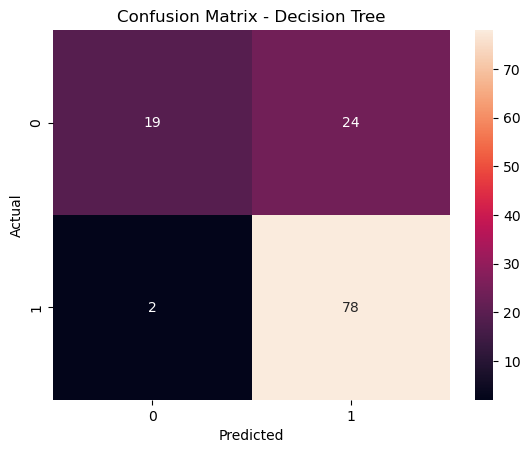

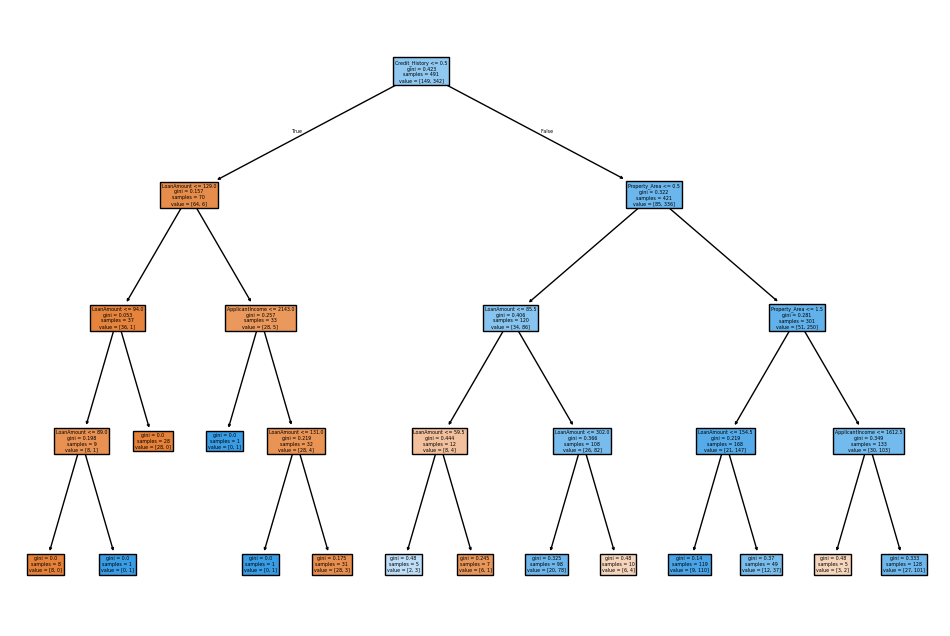

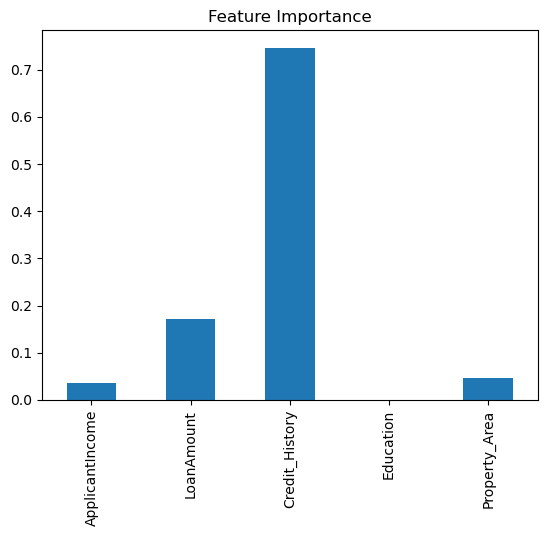

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 5")
print("\nSCENARIO 2: Decision Tree Classification")

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load Dataset 
df = pd.read_csv(r"C:\Users\nived\Downloads\train_u6lujuX_CVtuZ9i (1).csv")

#Handle Missing Values
df.fillna(df.mode().iloc[0], inplace=True)

#Encode Categorical Variables
le = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = le.fit_transform(df[column])

#Select Features
features = ['ApplicantIncome', 'LoanAmount', 
            'Credit_History', 'Education', 'Property_Area']
X = df[features]
y = df['Loan_Status']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

#Prediction
y_pred = dt.predict(X_test)

#Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Tree Structure Plot
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=features, filled=True)
plt.show()

# Feature Importance
importance = pd.Series(dt.feature_importances_, index=features)
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [ ]:
Steps Performed:

1.Imported required Python libraries 
2.Loaded Loan Prediction dataset
3.Handled missing values and encoded categorical variables
4.Split dataset into training (80%) and testing (20%) sets
5.Trained a Decision Tree classifier using DecisionTreeClassifier
6.Experimented with tree depth and pruning
7.Predicted loan status on test set
8.Evaluated performance using:
9.Accuracy
10.Precision / Recall / F1 Score
11.Analyzed feature importance
12.Observed signs of overfitting in deeper trees
13.Compared shallow vs deep trees


In [ ]:
Output:

-Decision Tree classified loan applications accurately
-Feature importance revealed Credit History and Applicant Income as most influential
-Shallow trees → less overfitting, deeper trees → more overfitting
-Accuracy was ~90–95% depending on depth
-Confusion matrix and feature importance plots were successfully generated